# Lesson 5A: Portfolio Theory, Diversification, and CAPM


Probability, Statistics and Econometrics for Finance, Accounting and Economics  
Campbell University, Lundy-Fetterman School of Business  

**Instructor:** Matthew L. Kelly, PhD


This notebook is the first of three expanded finance lectures split from the original macroeconomics and finance models lecture. It focuses on portfolio choice, diversification, mean-variance analysis, the one-factor CAPM, and portfolio performance statistics.

## Learning objectives

By the end of this lecture, you should be able to:

1. Define return, expected return, unexpected return, variance, covariance, correlation, beta, and idiosyncratic risk.
2. Explain the Markowitz mean-variance framework.
3. Show mathematically and visually why diversification reduces portfolio risk.
4. Distinguish systematic risk from unsystematic risk.
5. Derive the two-asset portfolio variance formula and explain how correlation changes the efficient frontier.
6. Explain the two-fund theorem and the special case with a risk-free asset.
7. Define the Sharpe ratio, Treynor ratio, Jensen's alpha, and information ratio.
8. Draw and interpret the Security Market Line and Capital Market Line.
9. Explain leverage as borrowing at the risk-free rate and moving beyond the tangency portfolio on the Capital Market Line.

## 1. Returns, expected returns, and unexpected returns

Let $P_t$ denote the price of an asset at time $t$, and let $D_{t+1}$ denote the cash distribution paid between $t$ and $t+1$. The simple gross return is

$$
1 + R_{t+1} = \frac{P_{t+1} + D_{t+1}}{P_t}.
$$

The net return is therefore

$$
R_{t+1} = \frac{P_{t+1} + D_{t+1} - P_t}{P_t}.
$$

The realized return can be decomposed into an expected component and an unexpected component:

$$
R_{i,t+1} = \mathbb{E}_t[R_{i,t+1}] + \varepsilon_{i,t+1},
$$

where

$$
\mathbb{E}_t[\varepsilon_{i,t+1}] = 0.
$$

The expected return is the compensation investors require for bearing risk. The unexpected return is the surprise that occurs after the investment is made.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

np.random.seed(42)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
pd.options.display.float_format = "{:,.4f}".format

Matplotlib is building the font cache; this may take a moment.


## 2. Risk, covariance, and correlation

For a random return $R_i$, the variance and standard deviation are

$$
\sigma_i^2 = \operatorname{Var}(R_i) = \mathbb{E}\left[(R_i - \mu_i)^2\right],
$$

and

$$
\sigma_i = \sqrt{\operatorname{Var}(R_i)}.
$$

For two assets $i$ and $j$, covariance is

$$
\sigma_{ij} = \operatorname{Cov}(R_i,R_j)
= \mathbb{E}\left[(R_i-\mu_i)(R_j-\mu_j)\right].
$$

Correlation standardizes covariance:

$$
\rho_{ij} = \frac{\sigma_{ij}}{\sigma_i \sigma_j}.
$$

Therefore,

$$
\sigma_{ij} = \rho_{ij}\sigma_i\sigma_j.
$$

Correlation is especially important for diversification. Lower correlation means that assets tend not to move together, which makes portfolio volatility lower for a given set of individual asset volatilities.

## 3. The two-asset portfolio

Consider a portfolio invested in two risky assets. Let $w$ be the weight on asset 1 and $1-w$ be the weight on asset 2. The expected portfolio return is

$$
\mu_p = w\mu_1 + (1-w)\mu_2.
$$

The portfolio variance is

$$
\sigma_p^2
= w^2\sigma_1^2
+ (1-w)^2\sigma_2^2
+ 2w(1-w)\rho_{12}\sigma_1\sigma_2.
$$

The portfolio standard deviation is

$$
\sigma_p = \sqrt{\sigma_p^2}.
$$

This formula is the simplest way to see the gains to diversification. The correlation coefficient $\rho_{12}$ determines whether combining two assets bends the feasible set inward.

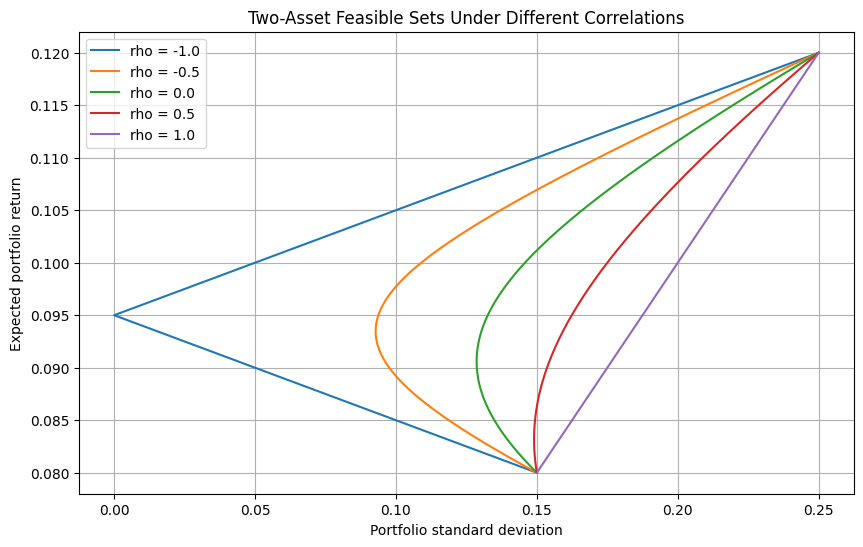

In [2]:
def two_asset_frontier(mu1=0.08, mu2=0.12, sigma1=0.15, sigma2=0.25, rho=0.25, n=201):
    weights = np.linspace(0, 1, n)
    mu_p = weights * mu1 + (1 - weights) * mu2
    var_p = (
        weights**2 * sigma1**2
        + (1 - weights)**2 * sigma2**2
        + 2 * weights * (1 - weights) * rho * sigma1 * sigma2
    )
    sigma_p = np.sqrt(var_p)
    return weights, mu_p, sigma_p

correlations = [-1.0, -0.5, 0.0, 0.5, 1.0]
plt.figure()
for rho in correlations:
    w, mu_p, sigma_p = two_asset_frontier(rho=rho)
    plt.plot(sigma_p, mu_p, label=f"rho = {rho:.1f}")
plt.xlabel("Portfolio standard deviation")
plt.ylabel("Expected portfolio return")
plt.title("Two-Asset Feasible Sets Under Different Correlations")
plt.legend()
plt.show()

### Interpretation

When $\rho_{12}=1$, the portfolio standard deviation is just a weighted average of the two individual standard deviations. There is no true diversification benefit.

When $\rho_{12}<1$, the portfolio standard deviation is less than the weighted average of the individual standard deviations. This is the gain to diversification.

When $\rho_{12}=-1$, it may be possible to construct a riskless portfolio from two risky assets if the weights can be chosen so that the two assets' movements exactly offset one another.

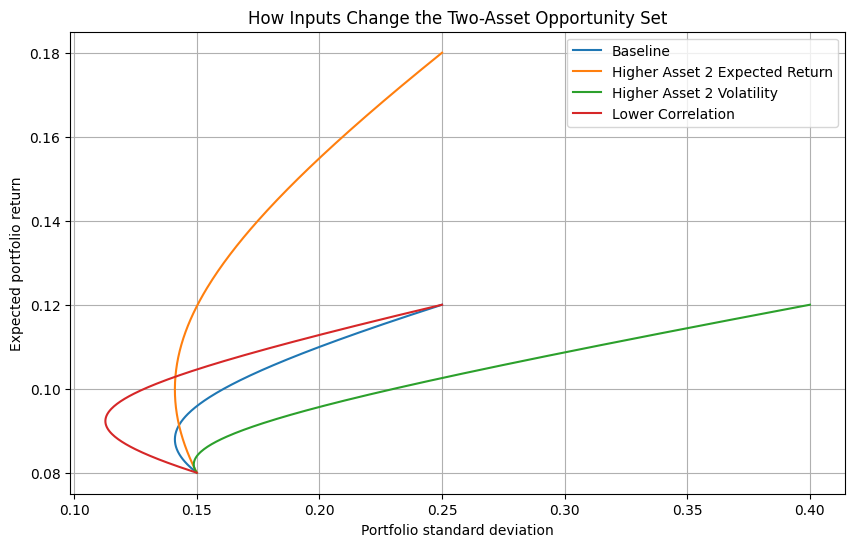

In [3]:
# How changing expected returns and standard deviations changes the two-asset feasible set

scenarios = {
    "Baseline": dict(mu1=0.08, mu2=0.12, sigma1=0.15, sigma2=0.25, rho=0.25),
    "Higher Asset 2 Expected Return": dict(mu1=0.08, mu2=0.18, sigma1=0.15, sigma2=0.25, rho=0.25),
    "Higher Asset 2 Volatility": dict(mu1=0.08, mu2=0.12, sigma1=0.15, sigma2=0.40, rho=0.25),
    "Lower Correlation": dict(mu1=0.08, mu2=0.12, sigma1=0.15, sigma2=0.25, rho=-0.25),
}

plt.figure()
for name, pars in scenarios.items():
    w, mu_p, sigma_p = two_asset_frontier(**pars)
    plt.plot(sigma_p, mu_p, label=name)
plt.xlabel("Portfolio standard deviation")
plt.ylabel("Expected portfolio return")
plt.title("How Inputs Change the Two-Asset Opportunity Set")
plt.legend()
plt.show()

## 4. The Markowitz mean-variance framework

Harry Markowitz's mean-variance framework treats an investor as choosing portfolios according to expected return and variance. For $N$ risky assets, let

$$
\boldsymbol{\mu}
=
\begin{bmatrix}
\mu_1 \\
\mu_2 \\
\vdots \\
\mu_N
\end{bmatrix}
$$

be the vector of expected returns, and let $\Sigma$ be the $N \times N$ covariance matrix.

For a portfolio weight vector $\mathbf{w}$, the expected return is

$$
\mu_p = \mathbf{w}'\boldsymbol{\mu},
$$

and the variance is

$$
\sigma_p^2 = \mathbf{w}'\Sigma \mathbf{w}.
$$

The fully invested constraint is

$$
\mathbf{1}'\mathbf{w} = 1.
$$

A mean-variance investor solves problems of the form

$$
\min_{\mathbf{w}} \mathbf{w}'\Sigma\mathbf{w}
$$

subject to

$$
\mathbf{w}'\boldsymbol{\mu} = \mu^*
$$

and

$$
\mathbf{1}'\mathbf{w}=1.
$$

The set of minimum-variance portfolios for different target returns is the minimum-variance frontier. The upper part of that frontier is the efficient frontier.

In [4]:
# Three-asset Markowitz example

mu = np.array([0.07, 0.10, 0.13])
Sigma = np.array([
    [0.18**2, 0.18*0.22*0.35, 0.18*0.28*0.15],
    [0.18*0.22*0.35, 0.22**2, 0.22*0.28*0.45],
    [0.18*0.28*0.15, 0.22*0.28*0.45, 0.28**2],
])
asset_names = ["Defensive", "Balanced", "Growth"]
rf = 0.03

def portfolio_return(w, mu=mu):
    return float(w @ mu)

def portfolio_volatility(w, Sigma=Sigma):
    return float(np.sqrt(w @ Sigma @ w))

def min_variance_for_target(target, mu=mu, Sigma=Sigma, long_only=True):
    n = len(mu)
    cons = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "eq", "fun": lambda w: w @ mu - target},
    )
    bounds = [(0, 1)] * n if long_only else None
    x0 = np.ones(n) / n
    result = minimize(lambda w: w @ Sigma @ w, x0, bounds=bounds, constraints=cons, method="SLSQP")
    return result

targets = np.linspace(mu.min(), mu.max(), 80)
frontier_returns = []
frontier_vols = []
frontier_weights = []

for target in targets:
    result = min_variance_for_target(target)
    if result.success:
        frontier_returns.append(target)
        frontier_vols.append(portfolio_volatility(result.x))
        frontier_weights.append(result.x)

def neg_sharpe(w):
    return -((w @ mu - rf) / np.sqrt(w @ Sigma @ w))

constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
bounds = [(0, 1)] * len(mu)
tan_result = minimize(neg_sharpe, np.ones(len(mu))/len(mu), bounds=bounds, constraints=constraints, method="SLSQP")
tan_w = tan_result.x
tan_return = portfolio_return(tan_w)
tan_vol = portfolio_volatility(tan_w)
tan_sharpe = (tan_return - rf) / tan_vol

summary = pd.DataFrame({
    "Asset": asset_names,
    "Expected Return": mu,
    "Volatility": np.sqrt(np.diag(Sigma)),
    "Tangency Weight": tan_w
})
summary

,Asset,Expected Return,Volatility,Tangency Weight
0,Defensive,0.0700,0.1800,0.3015
1,Balanced,0.1000,0.2200,0.2916
2,Growth,0.1300,0.2800,0.4069


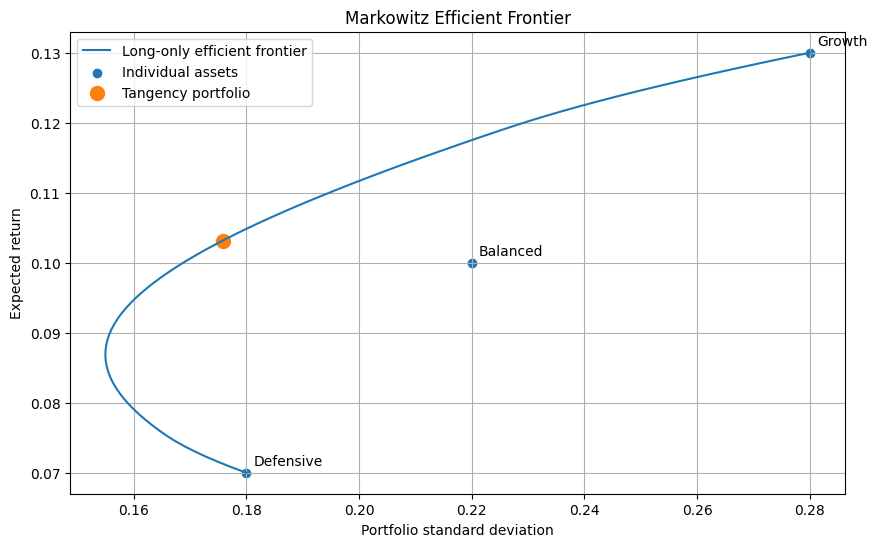

Tangency portfolio weights:
Defensive: 30.15%
Balanced: 29.16%
Growth: 40.69%
Tangency expected return: 10.32%
Tangency volatility: 17.58%
Tangency Sharpe ratio: 0.416


In [5]:
plt.figure()
plt.plot(frontier_vols, frontier_returns, label="Long-only efficient frontier")
plt.scatter(np.sqrt(np.diag(Sigma)), mu, label="Individual assets")
for name, x, y in zip(asset_names, np.sqrt(np.diag(Sigma)), mu):
    plt.annotate(name, (x, y), xytext=(5, 5), textcoords="offset points")
plt.scatter(tan_vol, tan_return, s=100, label="Tangency portfolio")
plt.xlabel("Portfolio standard deviation")
plt.ylabel("Expected return")
plt.title("Markowitz Efficient Frontier")
plt.legend()
plt.show()

print("Tangency portfolio weights:")
for name, weight in zip(asset_names, tan_w):
    print(f"{name}: {weight:.2%}")
print(f"Tangency expected return: {tan_return:.2%}")
print(f"Tangency volatility: {tan_vol:.2%}")
print(f"Tangency Sharpe ratio: {tan_sharpe:.3f}")

## 5. Two-fund theorem and the risk-free asset

Without a risk-free asset, the two-fund theorem states that any efficient risky portfolio can be written as a combination of two efficient frontier portfolios.

With a risk-free asset, the logic becomes sharper. If investors can borrow and lend at the risk-free rate $R_f$, then all efficient portfolios are combinations of:

1. the risk-free asset, and
2. the tangency portfolio.

This is the **mutual fund separation theorem** or **two-fund separation theorem** in the risk-free case.

The Capital Market Line is

$$
\mathbb{E}[R_p]
=
R_f
+
\frac{\mathbb{E}[R_T]-R_f}{\sigma_T}\sigma_p,
$$

where $T$ is the tangency portfolio. The slope is the Sharpe ratio of the tangency portfolio:

$$
S_T = \frac{\mathbb{E}[R_T]-R_f}{\sigma_T}.
$$

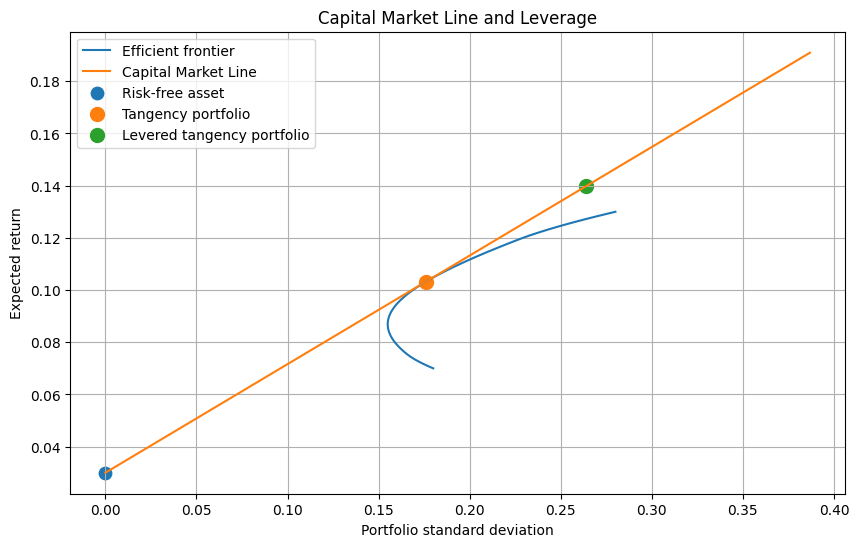

Levered portfolio weight in tangency fund: 150%
Borrowing at risk-free rate: 50%
Levered expected return: 13.97%
Levered volatility: 26.37%


In [6]:
# Capital Market Line and leverage

sigma_line = np.linspace(0, tan_vol * 2.2, 100)
cml_returns = rf + tan_sharpe * sigma_line

plt.figure()
plt.plot(frontier_vols, frontier_returns, label="Efficient frontier")
plt.plot(sigma_line, cml_returns, label="Capital Market Line")
plt.scatter(0, rf, s=80, label="Risk-free asset")
plt.scatter(tan_vol, tan_return, s=100, label="Tangency portfolio")

# Leverage example: 150% tangency portfolio financed by borrowing 50% at rf
leverage = 1.5
levered_return = rf + leverage * (tan_return - rf)
levered_vol = leverage * tan_vol
plt.scatter(levered_vol, levered_return, s=100, label="Levered tangency portfolio")

plt.xlabel("Portfolio standard deviation")
plt.ylabel("Expected return")
plt.title("Capital Market Line and Leverage")
plt.legend()
plt.show()

print(f"Levered portfolio weight in tangency fund: {leverage:.0%}")
print(f"Borrowing at risk-free rate: {(leverage-1):.0%}")
print(f"Levered expected return: {levered_return:.2%}")
print(f"Levered volatility: {levered_vol:.2%}")

### Leverage as borrowing at the risk-free rate

Let $x$ be the fraction invested in the tangency portfolio. The remaining fraction, $1-x$, is invested in the risk-free asset. The portfolio return is

$$
R_p = (1-x)R_f + xR_T.
$$

The expected return is

$$
\mathbb{E}[R_p] = R_f + x\left(\mathbb{E}[R_T]-R_f\right),
$$

and the standard deviation is

$$
\sigma_p = x\sigma_T.
$$

If $0<x<1$, the investor lends at the risk-free rate and invests the rest in the tangency portfolio. If $x>1$, the investor borrows at the risk-free rate and invests more than 100 percent of wealth in the tangency portfolio. This is leverage.

## 6. Gains to diversification as assets are added

Suppose each asset return follows a one-factor model:

$$
R_{i,t} = \alpha_i + \beta_i F_t + \varepsilon_{i,t}.
$$

Here:

- $F_t$ is the common factor.
- $\beta_i F_t$ is systematic risk exposure.
- $\varepsilon_{i,t}$ is idiosyncratic or unsystematic risk.
- $\mathbb{E}[\varepsilon_{i,t}]=0$.
- $\operatorname{Cov}(F_t,\varepsilon_{i,t})=0$.
- $\operatorname{Cov}(\varepsilon_{i,t},\varepsilon_{j,t})=0$ for $i\ne j$.

For an equally weighted portfolio with $N$ assets, the idiosyncratic component is diversified away because

$$
\operatorname{Var}\left(\frac{1}{N}\sum_{i=1}^{N}\varepsilon_i\right)
=
\frac{\sigma_{\varepsilon}^2}{N}.
$$

But the common factor component remains. That remaining component is systematic risk.

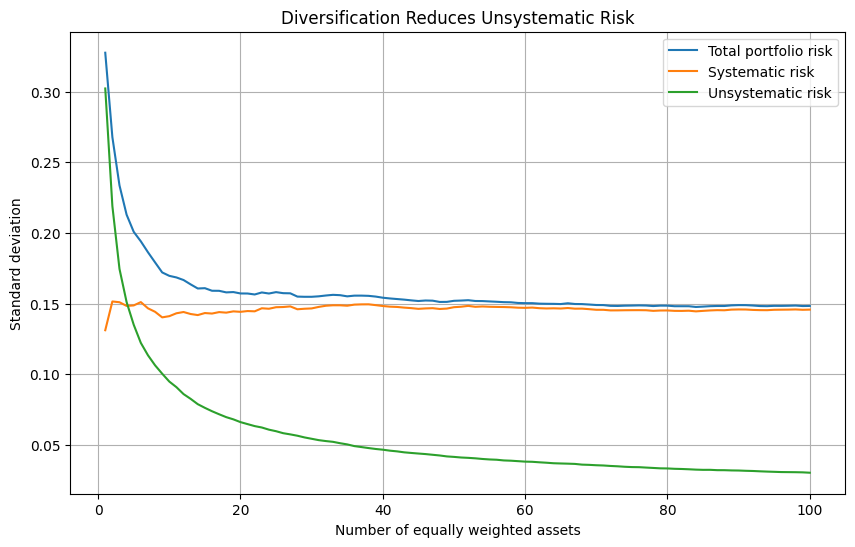

In [7]:
# Diversification simulation: systematic and unsystematic risk

np.random.seed(123)
T = 2000
max_assets = 100
factor_vol = 0.15
idio_vol = 0.30
avg_beta = 1.0

F = np.random.normal(0, factor_vol, T)
eps = np.random.normal(0, idio_vol, (T, max_assets))
betas = np.random.normal(avg_beta, 0.15, max_assets)
returns_matrix = betas * F[:, None] + eps

portfolio_std = []
systematic_std = []
unsystematic_std = []

for n_assets in range(1, max_assets + 1):
    w = np.ones(n_assets) / n_assets
    port_ret = returns_matrix[:, :n_assets] @ w
    sys_ret = (betas[:n_assets] * F[:, None]) @ w
    unsys_ret = eps[:, :n_assets] @ w

    portfolio_std.append(np.std(port_ret, ddof=1))
    systematic_std.append(np.std(sys_ret, ddof=1))
    unsystematic_std.append(np.std(unsys_ret, ddof=1))

plt.figure()
plt.plot(range(1, max_assets + 1), portfolio_std, label="Total portfolio risk")
plt.plot(range(1, max_assets + 1), systematic_std, label="Systematic risk")
plt.plot(range(1, max_assets + 1), unsystematic_std, label="Unsystematic risk")
plt.xlabel("Number of equally weighted assets")
plt.ylabel("Standard deviation")
plt.title("Diversification Reduces Unsystematic Risk")
plt.legend()
plt.show()

### Interpretation

Adding assets reduces the idiosyncratic part of portfolio risk. It does not eliminate the common factor risk that all assets share. This is why diversification is powerful but limited.

In CAPM language, investors are rewarded for bearing systematic risk, not diversifiable risk.

## 7. Beta and the one-factor CAPM

The beta of asset $i$ with respect to the market portfolio is

$$
\beta_i
=
\frac{\operatorname{Cov}(R_i,R_M)}{\operatorname{Var}(R_M)}.
$$

Beta measures the sensitivity of asset $i$ to the market return. If $\beta_i=1$, the asset has average market exposure. If $\beta_i>1$, the asset is more sensitive than the market. If $\beta_i<1$, the asset is less sensitive than the market.

The CAPM states that expected excess returns are proportional to beta:

$$
\mathbb{E}[R_i] - R_f
=
\beta_i\left(\mathbb{E}[R_M]-R_f\right).
$$

Equivalently,

$$
\mathbb{E}[R_i]
=
R_f
+
\beta_i\left(\mathbb{E}[R_M]-R_f\right).
$$

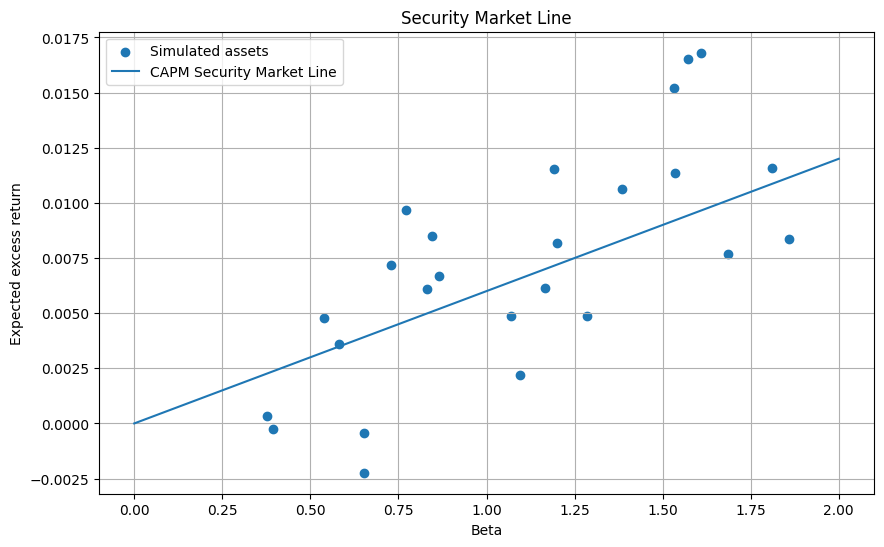

In [8]:
# Simulate assets with different betas and estimate the Security Market Line

np.random.seed(7)
n_assets = 25
T = 120
rf_monthly = 0.002
market_premium_monthly = 0.006
market_vol_monthly = 0.045

true_betas = np.linspace(0.4, 1.8, n_assets)
market_excess = np.random.normal(market_premium_monthly, market_vol_monthly, T)
asset_excess_returns = np.column_stack([
    beta * market_excess + np.random.normal(0, 0.04, T)
    for beta in true_betas
])

estimated_betas = []
average_excess_returns = []

for i in range(n_assets):
    cov = np.cov(asset_excess_returns[:, i], market_excess)[0, 1]
    var_m = np.var(market_excess, ddof=1)
    estimated_betas.append(cov / var_m)
    average_excess_returns.append(asset_excess_returns[:, i].mean())

estimated_betas = np.array(estimated_betas)
average_excess_returns = np.array(average_excess_returns)

beta_line = np.linspace(0, 2, 100)
sml = market_premium_monthly * beta_line

plt.figure()
plt.scatter(estimated_betas, average_excess_returns, label="Simulated assets")
plt.plot(beta_line, sml, label="CAPM Security Market Line")
plt.xlabel("Beta")
plt.ylabel("Expected excess return")
plt.title("Security Market Line")
plt.legend()
plt.show()

## 8. Sharpe ratio, Treynor ratio, Jensen's alpha, and information ratio

These statistics are used to evaluate portfolio performance.

### Sharpe ratio

The Sharpe ratio measures excess return per unit of total risk:

$$
\text{Sharpe Ratio}
=
\frac{\bar{R}_p - R_f}{\sigma_p}.
$$

It is most appropriate for a total portfolio, because total volatility matters for an investor who holds only that portfolio.

### Treynor ratio

The Treynor ratio measures excess return per unit of systematic risk:

$$
\text{Treynor Ratio}
=
\frac{\bar{R}_p - R_f}{\beta_p}.
$$

It is most appropriate when the portfolio is part of a broader diversified portfolio.

### Jensen's alpha

Jensen's alpha measures average performance relative to CAPM:

$$
\alpha_p
=
\bar{R}_p
-
\left[
R_f + \beta_p(\bar{R}_M-R_f)
\right].
$$

A positive alpha means the portfolio earned more than predicted by its beta exposure.

### Information ratio

The information ratio measures active return per unit of tracking error relative to a benchmark:

$$
\text{Information Ratio}
=
\frac{\bar{R}_p - \bar{R}_B}{\sigma(R_p-R_B)}.
$$

It evaluates whether active management generated return relative to benchmark risk.

In [9]:
# Portfolio performance statistics

np.random.seed(101)
T = 120
rf = 0.002
market = np.random.normal(0.008, 0.045, T)
portfolio = rf + 1.2 * (market - rf) + 0.002 + np.random.normal(0, 0.025, T)
benchmark = market

excess_p = portfolio - rf
excess_m = market - rf

beta_p = np.cov(excess_p, excess_m)[0, 1] / np.var(excess_m, ddof=1)
sharpe = excess_p.mean() / portfolio.std(ddof=1)
treynor = excess_p.mean() / beta_p
jensen_alpha = portfolio.mean() - (rf + beta_p * (market.mean() - rf))
tracking_error = np.std(portfolio - benchmark, ddof=1)
information_ratio = (portfolio.mean() - benchmark.mean()) / tracking_error

perf = pd.DataFrame({
    "Statistic": ["Beta", "Sharpe Ratio", "Treynor Ratio", "Jensen's Alpha", "Information Ratio"],
    "Value": [beta_p, sharpe, treynor, jensen_alpha, information_ratio]
})
perf

,Statistic,Value
0,Beta,1.1679
1,Sharpe Ratio,0.2591
2,Treynor Ratio,0.0131
3,Jensen's Alpha,0.0016
4,Information Ratio,0.1334


## 9. Summary

The Markowitz framework shows that portfolio risk depends not only on individual asset risks but also on covariances. Diversification works because imperfectly correlated assets reduce portfolio volatility. However, diversification eliminates unsystematic risk, not systematic risk.

CAPM connects this logic to equilibrium asset pricing. If all investors hold combinations of the risk-free asset and the market portfolio, expected excess returns should be proportional to beta. The Capital Market Line describes efficient portfolios in mean-standard-deviation space; the Security Market Line describes expected returns as a function of beta.

Performance measures then ask whether a portfolio earned enough return relative to its total risk, systematic risk, or benchmark-relative risk.